# Projet Méthodes Stochastiques — notebook

Code et simulations du projet proie-prédateur avec virus. Le contexte, la démarche
et la discussion des résultats sont dans le rapport ; ce notebook se concentre sur
le code qui charge les données, estime les paramètres et régénère les figures.

## Question 1 — modèle du virus (`virus4.csv`)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs

# Le fichier n'a pas d'en-tete : on nomme les colonnes a la main.
data = pd.read_csv("virus4.csv", header=None, names=["V", "P"])
V = data["V"].values
P = data["P"].values
N = len(data)
N

2000

### Estimation du pas de temps `dt`

In [2]:
# L'equation des predateurs est deterministe (dP = P(-1+V)dt) : on inverse le
# schema d'Euler pour estimer dt point par point, puis on moyenne. Le denominateur
# P(-1+V) s'annule si V ~ 1 OU si P ~ 0, on ecarte donc les points ou il est trop petit.
dP = np.diff(P)
denom = P[:-1] * (-1 + V[:-1])
masque = np.abs(denom) > 0.001

dt = np.mean(dP[masque] / denom[masque])
tau = N * dt
print(f'points ecartes : {(~masque).sum()} / {len(dP)} ({100 * (~masque).mean():.1f} %)')
print(f'dt ~ {dt:.4f}, tau ~ {tau:.1f}')

points ecartes : 84 / 1999 (4.2 %)
dt ~ 0.0150, tau ~ 30.0


### Axe des temps

In [3]:
t = np.arange(N) * dt   # axe des temps reconstruit a partir de dt
# Les donnees V, P sont visualisees directement sur la figure de comparaison ci-dessous.

### Comparaison avec le modèle de Lotka-Volterra classique (sans $X_t$)

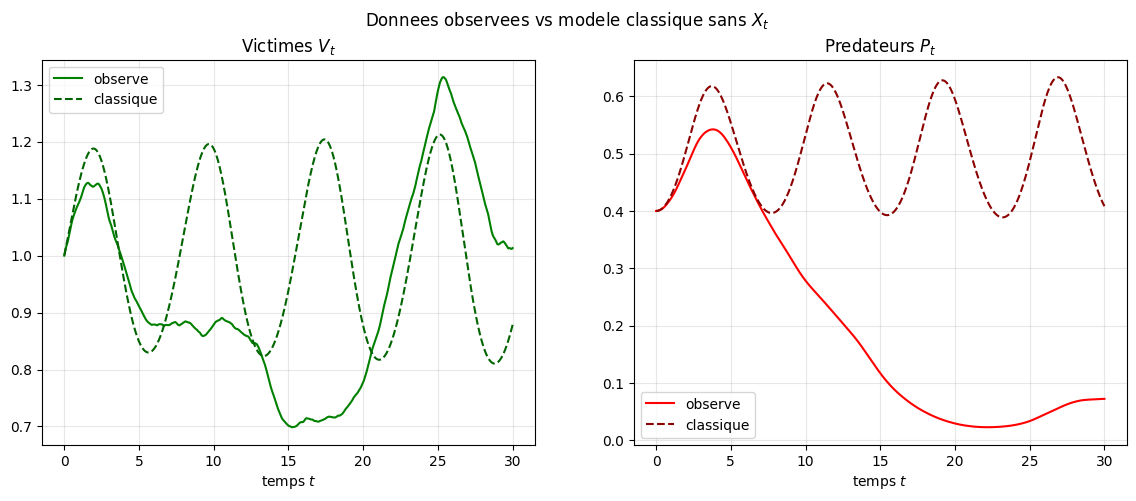

In [4]:
a, b, c, d = 2/3, 4/3, 1, 1

Vc = np.zeros(N)
Pc = np.zeros(N)
Vc[0], Pc[0] = V[0], P[0]   # memes conditions initiales que les donnees

# Euler explicite sur la meme grille de temps que les observations.
for i in range(N - 1):
    Vc[i+1] = Vc[i] + Vc[i] * (a - b * Pc[i]) * dt
    Pc[i+1] = Pc[i] + Pc[i] * (-c + d * Vc[i]) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Donnees observees vs modele classique sans $X_t$")

axes[0].plot(t, V, color="green", label="observe")
axes[0].plot(t, Vc, color="darkgreen", linestyle="--", label="classique")
axes[0].set_title("Victimes $V_t$")
axes[0].set_xlabel("temps $t$")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, P, color="red", label="observe")
axes[1].plot(t, Pc, color="darkred", linestyle="--", label="classique")
axes[1].set_title("Predateurs $P_t$")
axes[1].set_xlabel("temps $t$")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()

### Reconstruction du virus $X_t$

In [5]:
# Discretisation directe de l'equation des proies :
#   V[i] - V[i-1] = V[i-1] (2/3 - 4/3 P[i-1] + X[i-1]) dt
# d'ou X[i-1] = (V[i]-V[i-1]) / (V[i-1] dt) - 2/3 + 4/3 P[i-1].
dV = np.diff(V)
X = dV / (V[:-1] * dt) - 2/3 + 4/3 * P[:-1]
tX = t[:-1]   # X[k] est attache au temps t[k]

# Artefact deterministe, sauvegarde pour que tout le monde reparte de la meme serie.
pd.DataFrame({"t": tX, "X": X}).to_csv("virus4_Xt.csv", index=False)
print(f"X reconstruit : {len(X)} points")

X reconstruit : 1999 points


### $X_t$ et ses différences $\Delta X_t$

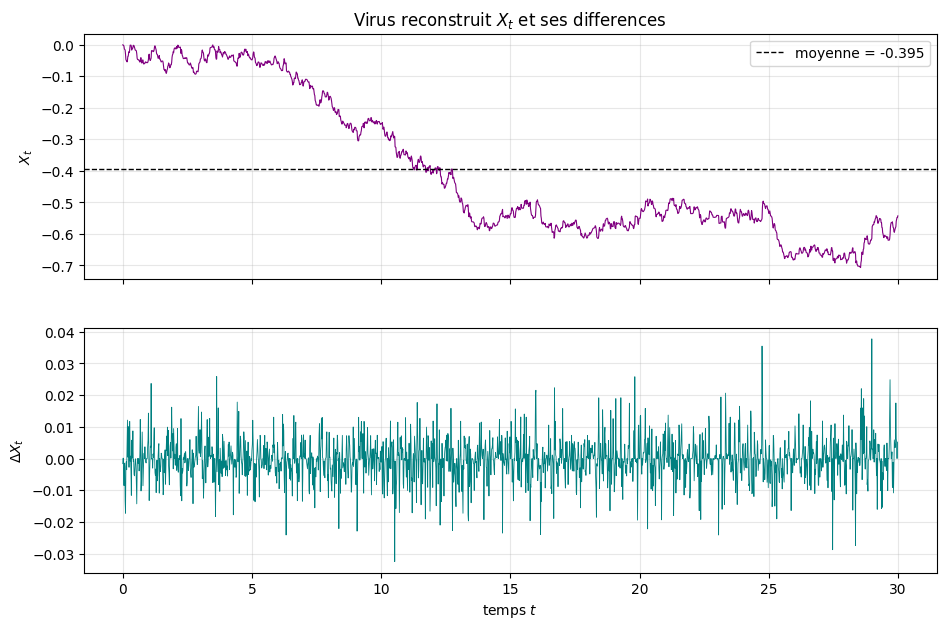

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(tX, X, color="purple", lw=0.8)
axes[0].axhline(X.mean(), color="black", ls="--", lw=1, label=f"moyenne = {X.mean():.3f}")
axes[0].set_ylabel("$X_t$")
axes[0].set_title("Virus reconstruit $X_t$ et ses differences")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(tX[:-1], np.diff(X), color="teal", lw=0.6)
axes[1].set_xlabel("temps $t$")
axes[1].set_ylabel(r"$\Delta X_t$")
axes[1].grid(alpha=0.3)

plt.savefig("figures/virus4_Xt.png", dpi=150, bbox_inches="tight")
plt.show()

### Statistiques de $X_t$ et $\Delta X_t$

Pour les différences, l'écart-type brut dépend du pas `dt` ; l'échelle qui a un sens est le
coefficient de diffusion $\sigma = \text{std}(\Delta X)/\sqrt{dt}$. On regarde aussi
l'asymétrie et la kurtosis pour juger de la normalité des différences.

In [7]:
dX = np.diff(X)
sigma = dX.std() / np.sqrt(dt)   # coefficient de diffusion, independant de dt

stats = pd.DataFrame(
    {"moyenne": [X.mean(), dX.mean()], "ecart-type": [X.std(), dX.std()]},
    index=["X_t", "dX_t"],
)
print(stats)
print(f"\nsigma = std(dX)/sqrt(dt) = {sigma:.4f}")
print(f"differences dX : asymetrie = {scs.skew(dX):.2f}, kurtosis exces = {scs.kurtosis(dX):.2f}")

       moyenne  ecart-type
X_t  -0.395169    0.227935
dX_t -0.000271    0.006377

sigma = std(dX)/sqrt(dt) = 0.0521
differences dX : asymetrie = 0.03, kurtosis exces = 3.33


### Gaussianité des différences $\Delta X_t$

On compare l'histogramme des différences à une loi normale de mêmes moyenne et écart-type.

test KS (normalite des differences) : D = 0.0881, p-value = 6.04e-14


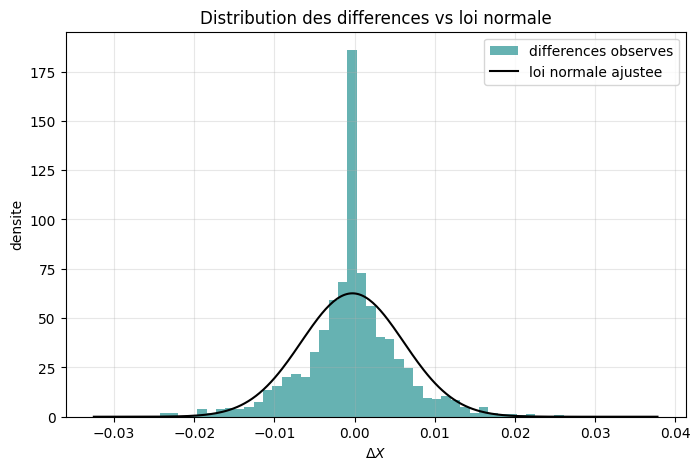

In [8]:
loi = scs.norm(dX.mean(), dX.std())   # normale calee sur moyenne et ecart-type des differences
ks = scs.kstest(dX, loi.cdf)
print(f"test KS (normalite des differences) : D = {ks.statistic:.4f}, p-value = {ks.pvalue:.2e}")
xx = np.linspace(dX.min(), dX.max(), 300)

plt.figure(figsize=(8, 5))
plt.hist(dX, bins=60, density=True, color="teal", alpha=0.6, label="differences observes")
plt.plot(xx, loi.pdf(xx), color="black", lw=1.5, label="loi normale ajustee")
plt.xlabel(r"$\Delta X$")
plt.ylabel("densite")
plt.title("Distribution des differences vs loi normale")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("figures/virus4_dXt_hist.png", dpi=150, bbox_inches="tight")
plt.show()

### Estimation des candidats : Ornstein-Uhlenbeck et brownien avec dérive

In [9]:
# OU : regression des differences sur le niveau
#   dX_i = theta*mu*dt - theta*dt*X_i + sigma*dB_i
pente, ord0 = np.polyfit(X[:-1], dX, 1)
theta = -pente / dt
mu = ord0 / (-pente)
sigma = (dX - (pente * X[:-1] + ord0)).std() / np.sqrt(dt)
# Brownien avec derive : moments des differences
nu = dX.mean() / dt
sigma_d = dX.std() / np.sqrt(dt)
print(f'OU     : theta = {theta:.3f}, mu = {mu:.3f}, sigma = {sigma:.3f}')
print(f'derive : nu = {nu:.4f}, sigma = {sigma_d:.3f}')

OU     : theta = 0.069, mu = -0.657, sigma = 0.052
derive : nu = -0.0181, sigma = 0.052


### Test des candidats par leurs residus

derive : p-value normalite = 6.0e-14 | correlation residus consecutifs = 0.26


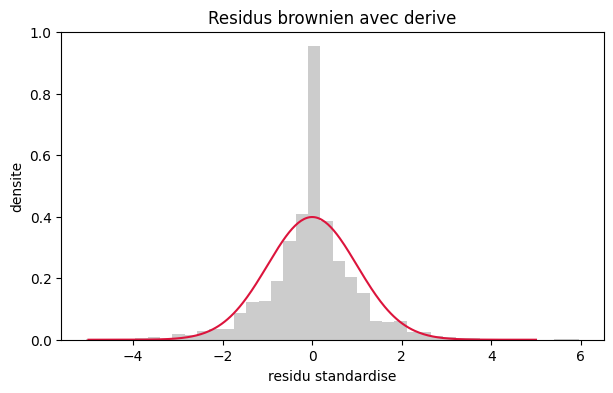

OU     : p-value normalite = 2.8e-14 | correlation residus consecutifs = 0.26


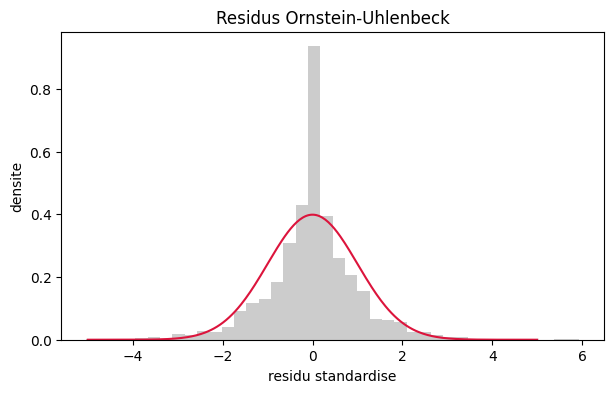

In [10]:
# Sous dX = a(X)dt + sigma dB, le residu standardise
#   eps_i = (dX_i - a(X_i)dt) / (sigma sqrt(dt)) = dB_i / sqrt(dt)
# est un increment brownien reduit, donc doit suivre N(0,1) i.i.d.
eps_ou = (dX - theta * (mu - X[:-1]) * dt) / (sigma * np.sqrt(dt))
eps_d = (dX - nu * dt) / (sigma_d * np.sqrt(dt))

for nom, eps, fname, titre in [('derive', eps_d, 'virus4_residus_derive.png', 'brownien avec derive'),
                               ('OU', eps_ou, 'virus4_residus_ou.png', 'Ornstein-Uhlenbeck')]:
    p_loi = scs.kstest(eps, 'norm').pvalue            # loi : KS a un echantillon contre N(0,1)
    corr = np.corrcoef(eps[:-1], eps[1:])[0, 1]        # independance : residus consecutifs
    print('%-7s: p-value normalite = %.1e | correlation residus consecutifs = %.2f' % (nom, p_loi, corr))
    plt.figure(figsize=(7, 4))
    plt.hist(eps, bins=40, density=True, color='0.8')
    g = np.linspace(-5, 5, 300)
    plt.plot(g, scs.norm.pdf(g), color='crimson')
    plt.xlabel('residu standardise'); plt.ylabel('densite'); plt.title('Residus ' + titre)
    plt.savefig('figures/' + fname, dpi=150, bbox_inches='tight')
    plt.show()

### Bruit à mémoire : OU sur les résidus du candidat Ornstein-Uhlenbeck

phi = 0.257
bruit colore : p-value normalite = 4.3e-14 | correlation innovations consecutives = 0.023


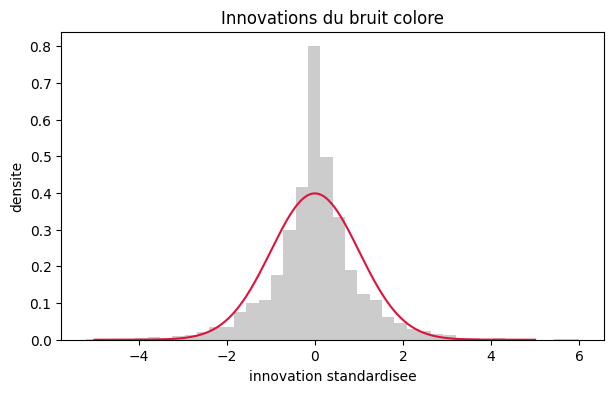

In [11]:
# Bruit à mémoire : le bruit n'est plus blanc mais garde une memoire d'un pas au suivant,
# soit un OU sur le bruit, ce qui revient a un AR(1) sur les residus eps_i = phi eps_{i-1} + eta_i.
# On regresse eps sur son passe ; les innovations eta doivent etre N(0,1) i.i.d.
phi, _ = np.polyfit(eps_ou[:-1], eps_ou[1:], 1) #par régression linéaire : phi = pente 
eta = eps_ou[1:] - phi * eps_ou[:-1]      
eta = (eta - eta.mean()) / eta.std()      # standardisees pour comparer a N(0,1)
print(f'phi = {phi:.3f}')
p_loi = scs.kstest(eta, 'norm').pvalue  #on teste la gaussianité d'eta
corr = np.corrcoef(eta[:-1], eta[1:])[0, 1]
print('bruit colore : p-value normalite = %.1e | correlation innovations consecutives = %.3f' % (p_loi, corr))
plt.figure(figsize=(7, 4))
plt.hist(eta, bins=40, density=True, color='0.8')
g = np.linspace(-5, 5, 300)
plt.plot(g, scs.norm.pdf(g), color='crimson')
plt.xlabel('innovation standardisee'); plt.ylabel('densite'); plt.title('Innovations du bruit colore')
plt.savefig('figures/virus4_residus_colore.png', dpi=150, bbox_inches='tight')
plt.show()

nu = 2.44
innovations : p-value KS contre Student = 1.8e-02 (rappel gaussienne : 4.3e-14)


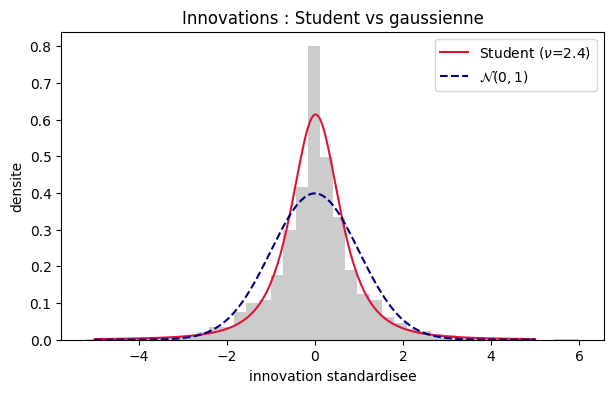

In [12]:
# La memoire etant captee par l'AR(1), il reste a corriger la loi des innovations.
# Leurs queues lourdes invitent a tester une loi de Student plutot que gaussienne.
# (NB : on sort ici du cadre brownien, ou les increments sont gaussiens par construction.)
nu, loc, sc = scs.t.fit(eta)
p_t = scs.kstest(eta, 't', args=(nu, loc, sc)).pvalue
print(f'nu = {nu:.2f}')
print('innovations : p-value KS contre Student = %.1e (rappel gaussienne : %.1e)'
      % (p_t, scs.kstest(eta, 'norm').pvalue))
plt.figure(figsize=(7, 4))
plt.hist(eta, bins=40, density=True, color='0.8')
g = np.linspace(-5, 5, 300)
plt.plot(g, scs.t.pdf(g, nu, loc, sc), color='crimson', label=f'Student ($\\nu$={nu:.1f})')
plt.plot(g, scs.norm.pdf(g), color='navy', ls='--', label=r'$\mathcal{N}(0,1)$')
plt.xlabel('innovation standardisee'); plt.ylabel('densite'); plt.title('Innovations : Student vs gaussienne')
plt.legend()
plt.savefig('figures/virus4_innovations_student.png', dpi=150, bbox_inches='tight')
plt.show()

## Une echelle de temps differente : Ornstein-Uhlenbeck au pas dilate
On suppose X gouverne par un OU. A chaque pas dilate dt_k = k*dt on ajuste l'OU par regression
et on teste ses residus standardises : independance (autocorrelation) et normalite (KS vs N(0,1)).

k=1 dt=0.015 rho1=+0.257 KS-p=2.783e-14
k=2 dt=0.030 rho1=+0.063 KS-p=4.585e-02
k=3 dt=0.045 rho1=+0.036 KS-p=8.231e-01
k=4 dt=0.060 rho1=+0.009 KS-p=8.786e-01
k=5 dt=0.075 rho1=+0.030 KS-p=2.191e-01
k=6 dt=0.090 rho1=-0.049 KS-p=7.402e-01


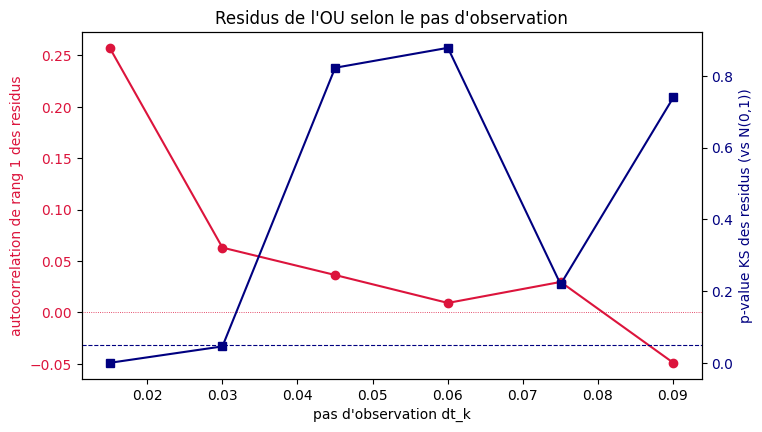

In [13]:
# residus standardises de l'OU ajuste (regression) au pas dilate k*dt
def residus_std(k):
    Xk = X[::k]; dXk = np.diff(Xk)
    p, o = np.polyfit(Xk[:-1], dXk, 1)
    r = dXk - (p * Xk[:-1] + o)
    return r / r.std()

ks = [1, 2, 3, 4, 5, 6]            # pas d'interet : dt_k de 0.015 a 0.09
dtk_list, rho_list, p_list = [], [], []
for kk in ks:
    eps = residus_std(kk)
    dtk_list.append(dt * kk)
    rho_list.append(np.corrcoef(eps[:-1], eps[1:])[0, 1])
    p_list.append(scs.kstest(eps, 'norm').pvalue)
    print('k=%d dt=%.3f rho1=%+.3f KS-p=%.3e' % (kk, dt * kk, rho_list[-1], p_list[-1]))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(dtk_list, rho_list, 'o-', color='crimson')
ax1.axhline(0, color='crimson', lw=0.6, ls=':')
ax1.set_xlabel("pas d'observation dt_k")
ax1.set_ylabel('autocorrelation de rang 1 des residus', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax2 = ax1.twinx()
ax2.plot(dtk_list, p_list, 's-', color='navy')
ax2.axhline(0.05, color='navy', lw=0.8, ls='--')
ax2.set_ylabel('p-value KS des residus (vs N(0,1))', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
plt.title("Residus de l'OU selon le pas d'observation")
plt.savefig('figures/virus4_pas_dilate.png', dpi=150, bbox_inches='tight')
plt.show()

### OU au pas dilate retenu (k=4) : parametres et residus standardises

OU au pas dilate : theta=0.078 mu=-0.628 sigma=0.0611
residus : rho1=0.009  KS-p=0.879


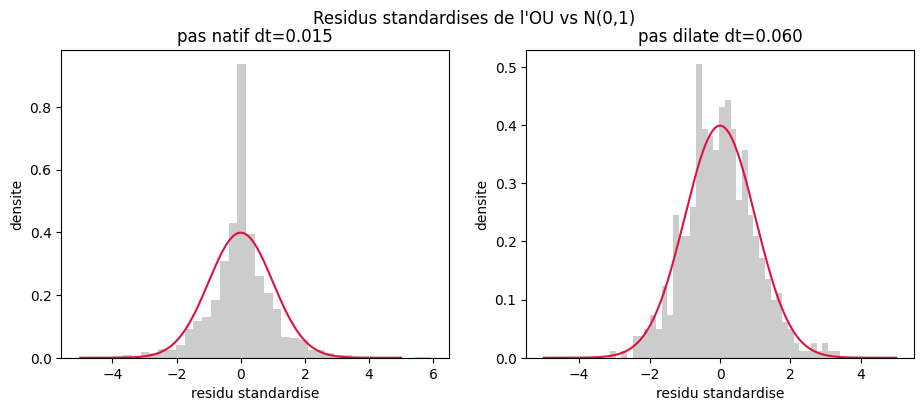

In [14]:
k = 4   # pas retenu : quadruple (dt_k ~ 0.060), residus les mieux comportes
Xk = X[::k]; dtk = dt * k; dXk = np.diff(Xk)
pente, ord0 = np.polyfit(Xk[:-1], dXk, 1)
theta = -pente / dtk
mu = ord0 / (-pente)
sigma = (dXk - (pente * Xk[:-1] + ord0)).std() / np.sqrt(dtk)
eps = residus_std(k)
print('OU au pas dilate : theta=%.3f mu=%.3f sigma=%.4f' % (theta, mu, sigma))
print('residus : rho1=%.3f  KS-p=%.3f' % (np.corrcoef(eps[:-1], eps[1:])[0, 1], scs.kstest(eps, 'norm').pvalue))

# residus standardises de l'OU, au pas natif puis au pas dilate retenu
fig, ax = plt.subplots(1, 2, figsize=(11, 4)); g = np.linspace(-5, 5, 300)
for a, kk, lab in [(ax[0], 1, 'pas natif dt=%.3f' % dt), (ax[1], k, 'pas dilate dt=%.3f' % dtk)]:
    a.hist(residus_std(kk), bins=40, density=True, color='0.8')
    a.plot(g, scs.norm.pdf(g), color='crimson')
    a.set_title(lab); a.set_xlabel('residu standardise'); a.set_ylabel('densite')
plt.suptitle("Residus standardises de l'OU vs N(0,1)")
plt.savefig('figures/virus4_residus_dilate.png', dpi=150, bbox_inches='tight')
plt.show()

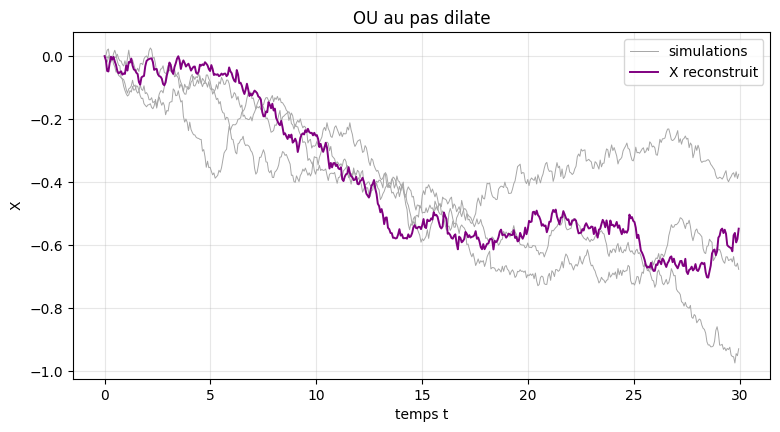

In [15]:
# trajectoires de l'OU (solution exacte) au pas dilate, comparees au virus reconstruit
rng = np.random.default_rng(0)
tk, Xk = tX[::k], X[::k]
def brownien(n, pas):
    return np.concatenate([[0.0], np.cumsum(rng.normal(0, np.sqrt(pas), n - 1))])
def simule_ou(tt, pas, theta, mu, sigma, x0=0.0):
    B = brownien(len(tt), pas); dB = np.diff(B)
    ito = np.concatenate([[0.0], np.cumsum(np.exp(theta * tt[:-1]) * dB)])
    return mu + (x0 - mu) * np.exp(-theta * tt) + sigma * np.exp(-theta * tt) * ito

plt.figure(figsize=(9, 4.5))
for j in range(3):
    plt.plot(tk, simule_ou(tk, dtk, theta, mu, sigma), color='0.65', lw=0.7,
             label='simulations' if j == 0 else None)
plt.plot(tk, Xk, color='purple', lw=1.4, label='X reconstruit')
plt.xlabel('temps t'); plt.ylabel('X'); plt.title('OU au pas dilate'); plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures/virus4_sim_ou.png', dpi=150, bbox_inches='tight')
plt.show()

## Question 2 — loi de l'extinction (Bernoulli)
Pour une population, Y = 1 si sa densite passe sous 0.01 sur [0, tau] : c'est l'indicatrice de
l'extinction, donc Y ~ Bernoulli(p). On estime p par la frequence d'extinction sur M simulations
du systeme (V,P) avec X suivant l'OU retenu.

victimes    : p = 0.0008  ->  Y ~ Bernoulli(0.001)
predateurs  : p = 0.3923  ->  Y ~ Bernoulli(0.392)


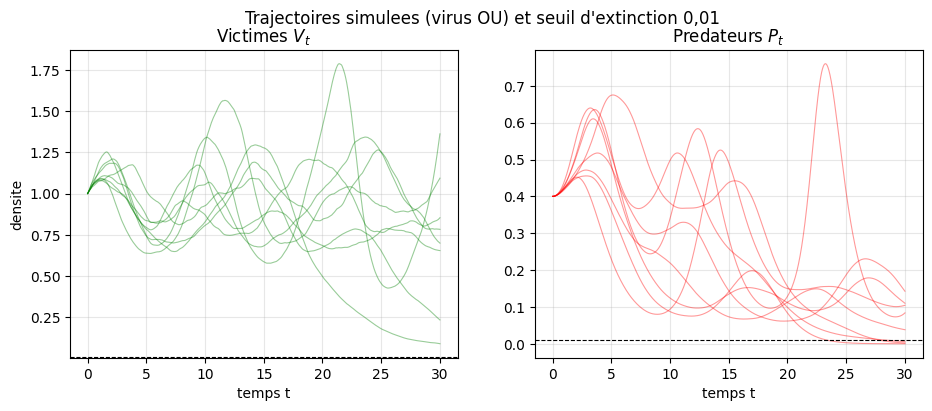

In [16]:
# X ~ OU retenu injecte dans (V,P) au pas natif ; extinction si V ou P passe sous 0.01 sur [0, tau]
def simule_ext(M, n_traj=8, seed=0):
    g = np.random.default_rng(seed)
    Vc = np.full(M, V[0]); Pc = np.full(M, P[0]); Xc = np.full(M, X[0])
    extV = np.zeros(M, bool); extP = np.zeros(M, bool)
    Vtr = np.zeros((n_traj, N)); Ptr = np.zeros((n_traj, N)); Vtr[:, 0] = V[0]; Ptr[:, 0] = P[0]
    for i in range(N - 1):
        Xc = Xc + theta * (mu - Xc) * dt + sigma * np.sqrt(dt) * g.standard_normal(M)
        Vc = np.clip(Vc + Vc * (2/3 - 4/3 * Pc + Xc) * dt, 0, 1e6)
        Pc = np.clip(Pc + Pc * (-1 + Vc) * dt, 0, 1e6)
        Vtr[:, i + 1] = Vc[:n_traj]; Ptr[:, i + 1] = Pc[:n_traj]
        extV |= Vc <= 0.01; extP |= Pc <= 0.01
    return extV, extP, Vtr, Ptr

M = 10000
extV, extP, Vtr, Ptr = simule_ext(M)
# Y = indicatrice d'extinction -> loi de Bernoulli(p), p estime par la frequence sur M tirages
for nom, e in [('victimes', extV), ('predateurs', extP)]:
    print('%-11s : p = %.4f  ->  Y ~ Bernoulli(%.3f)' % (nom, e.mean(), e.mean()))

fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for j in range(Vtr.shape[0]):
    ax[0].plot(t, Vtr[j], color='green', alpha=0.4, lw=0.8)
    ax[1].plot(t, Ptr[j], color='red', alpha=0.4, lw=0.8)
for a, lab in zip(ax, ['Victimes $V_t$', 'Predateurs $P_t$']):
    a.axhline(0.01, color='k', ls='--', lw=0.8); a.set_xlabel('temps t'); a.set_title(lab); a.grid(alpha=0.3)
ax[0].set_ylabel('densite')
plt.suptitle("Trajectoires simulees (virus OU) et seuil d'extinction 0,01")
plt.savefig('figures/virus4_extinction_trajectoires.png', dpi=150, bbox_inches='tight')
plt.show()